In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

In [106]:
mpg = sns.load_dataset("mpg")
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [107]:
mpg.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [108]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [109]:
mpg.dropna(inplace=True)

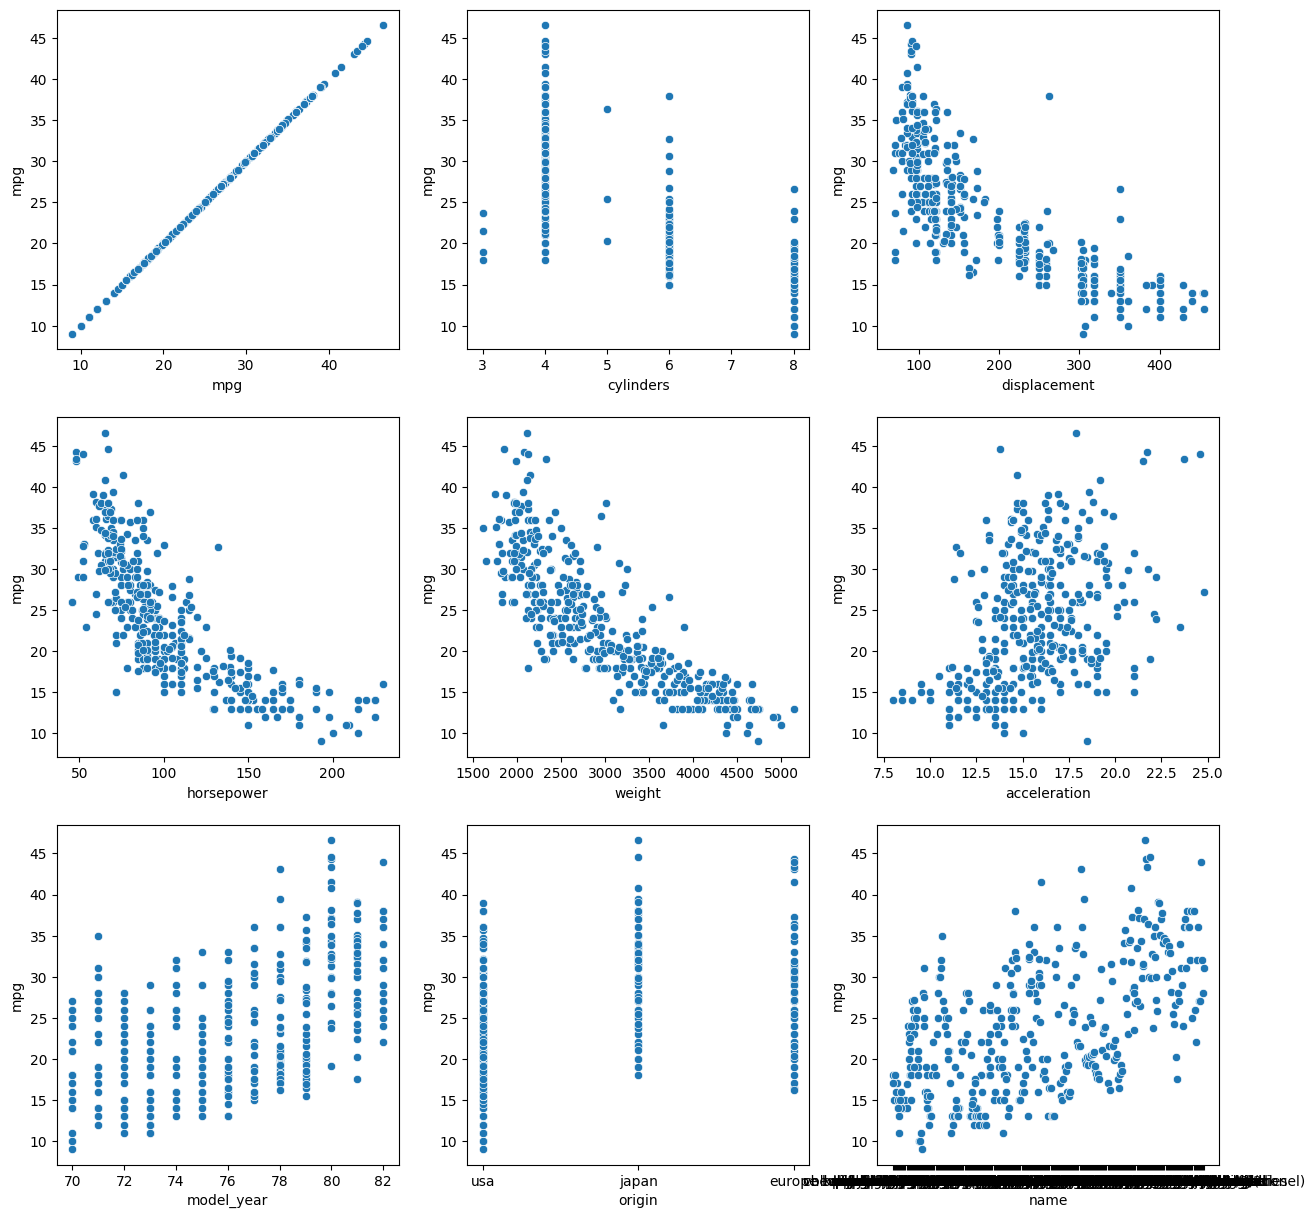

In [110]:
plt.subplots(3, 3, figsize=(15, 15))
for col in mpg.columns:
    plt.subplot(3, 3, mpg.columns.get_loc(col) + 1)
    sns.scatterplot(data=mpg, x=col, y="mpg")
plt.show()

Displacement, horsepower, weight and acceleration are interesting features

In [111]:

mpg.drop(columns=["name", "origin"], inplace=True)

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
mpg.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 24.5 KB


In [114]:
X, y = mpg.drop(columns=["mpg"]), mpg["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((313, 6), (79, 6), (313,), (79,))

In [115]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
import numpy as np

In [116]:
def train_reg_model(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    MAE = mean_absolute_error(y_test, y_pred)
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)

    return {"MAE": MAE, "MSE": MSE, "RMSE": RMSE}

In [117]:
model = LinearRegression()
train_reg_model(X_train, X_test, y_train, y_test, model)

{'MAE': 2.503860089776125,
 'MSE': 10.502370329417303,
 'RMSE': np.float64(3.2407360783342574)}

In [118]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline


lin_reg_model = LinearRegression()
lin_reg_scaled_model = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
poly_reg_deg1_model = Pipeline([("poly", PolynomialFeatures(degree=1)), ("model", LinearRegression())])
poly_reg_deg2_model = Pipeline([("poly", PolynomialFeatures(degree=2)), ("model", LinearRegression())])
poly_reg_deg3_model = Pipeline([("poly", PolynomialFeatures(degree=3)), ("model", LinearRegression())])

models = [lin_reg_model, lin_reg_scaled_model, poly_reg_deg1_model, poly_reg_deg2_model, poly_reg_deg3_model]


In [119]:
import pandas as pd

Models_evaluation = pd.DataFrame(columns=models, index=["MAE", "MSE", "RMSE"])

for model in models:
    Models_evaluation[model] = train_reg_model(X_train, X_test, y_train, y_test, model)


In [120]:
Models_evaluation.head()

,LinearRegression(),"(StandardScaler(), LinearRegression())","(PolynomialFeatures(degree=1), LinearRegression())","(PolynomialFeatures(), LinearRegression())","(PolynomialFeatures(degree=3), LinearRegression())"
MAE,2.503860,2.503860,2.503860,1.980477,2.037549
MSE,10.502370,10.502370,10.502370,7.419858,8.010502
RMSE,3.240736,3.240736,3.240736,2.723942,2.830283
